---
title: "Climate Change in Philadelphia"
description: "To what extent has Philadelphia weather become more volatile?"
author: "Fiona Herzog"
date: "02/07/2026"
categories:
  - visualization
  - data stories
---

## Is there a relationship between geography and personality?

Since moving to Philadelphia, I've been told that the climates that I've grown accustomed to are very different to even just 10-20 years ago. Thus, this is a data exploration on just how much Philadelphia weather has not only changed, but has also become more volatile as the effects of climate change have gotten all the more apparent. 

Thus, in this data exploration, we will examine many different facets of Phildelphia weather across the ten year time span to answer this question. 

#### Setup my environement

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Load the dataset

In [4]:
weather_df = pd.read_csv('data/philadelphia_weather_2005_to_2025.csv')
weather_df = weather_df.assign(date=pd.to_datetime(weather_df['date']))

### Normalization of Extreme Heat

Has there been a significant increase in the frequency of "extreme" heatdays? To answer this question, we define an "extreme heat day" as any day where the highest temperature of the day exceeds 90 degrees Fahrenheit. We will then track the trends in the number of extreme heat days by year to determine whether there is any significant trend. 

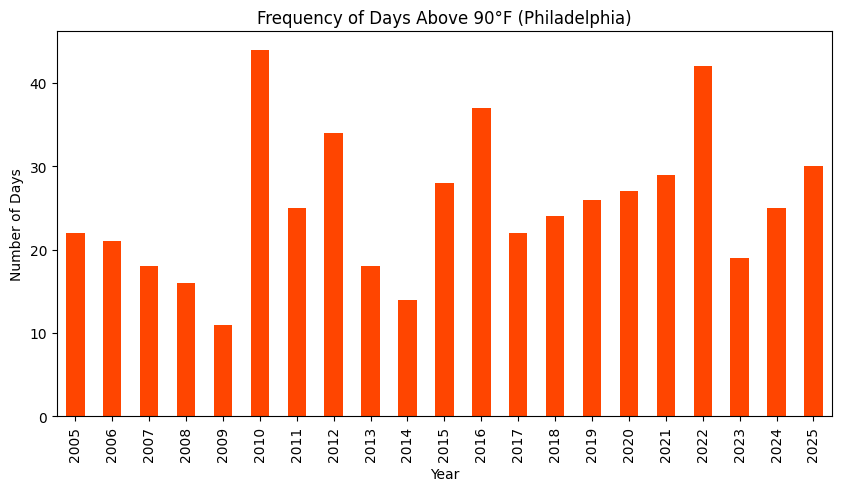

In [5]:
# defining extreme heat
extreme_heat = weather_df[weather_df['high'] > 90]
# calculating annual extreme heat frequency
heat_yearly_counts = extreme_heat.groupby('year').size()
# plotting our findings
plt.figure(figsize=(10, 5))
heat_yearly_counts.plot(kind='bar', color='orangered')
plt.title('Frequency of Days Above 90°F (Philadelphia)')
plt.ylabel('Number of Days')
plt.xlabel('Year')
plt.show()

Overall, there seems to be a steady increase in the number of days that reach above ninety degrees. From the years of 2017 to 2022, there is only increases, with 2022 reaching a significant spike. While this data is not large enough compared to datasets of hundreds of years to see the truly drastic shift in temperature, it does show an increase in the number of hot days in Philadelphia. 

### Volatility of the Rain Cycle

Have rainfall patterns changed from steady percipitation to more concentrated bursts of rain? We will look at the ratio of light rain days to heavy rain days per year. In this question, heavy rain is defined as anything above one inch. 

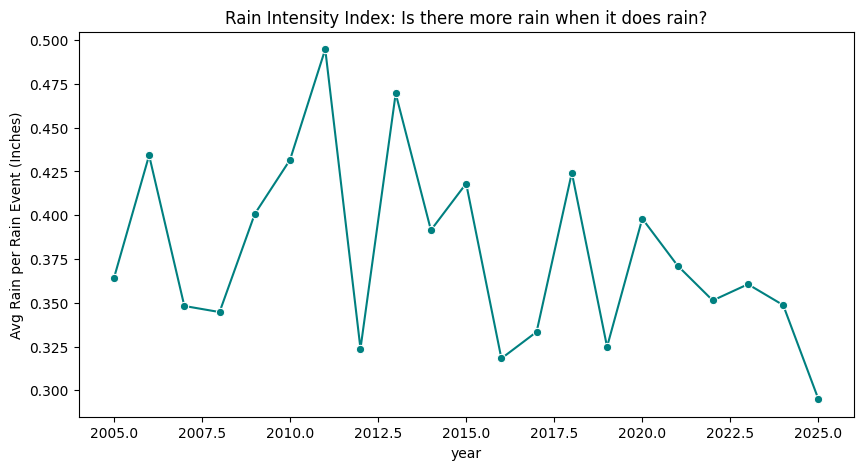

In [6]:
# defining heavy rain
weather_df['is_heavy_rain'] = weather_df['rain'] > 1.0

# Calculate annual heavy rain events
heavy_rain_annual = weather_df[weather_df['is_heavy_rain']].groupby('year').size()

# Calculate annual rain frequency
rainy_days = weather_df[weather_df['rain'] > 0].groupby('year')
intensity_index = rainy_days['rain'].sum() / rainy_days.size()

plt.figure(figsize=(10, 5))
sns.lineplot(x=intensity_index.index, y=intensity_index.values, marker='o', color='teal')
plt.title('Rain Intensity Index: Is there more rain when it does rain?')
plt.ylabel('Avg Rain per Rain Event (Inches)')
plt.show() 

The line graph goes up and down across each year pretty consistently, indicating that average rain amount for each time it rains varies a lot. While the highest average rain count happens in 2011, the lowest is this most recent year of 2025, with an overall trend downwards in amount of rain in the most recent years. The volatility of the amount of rain reached a peak in 2012, reaching a local minimum after the initial peak. 

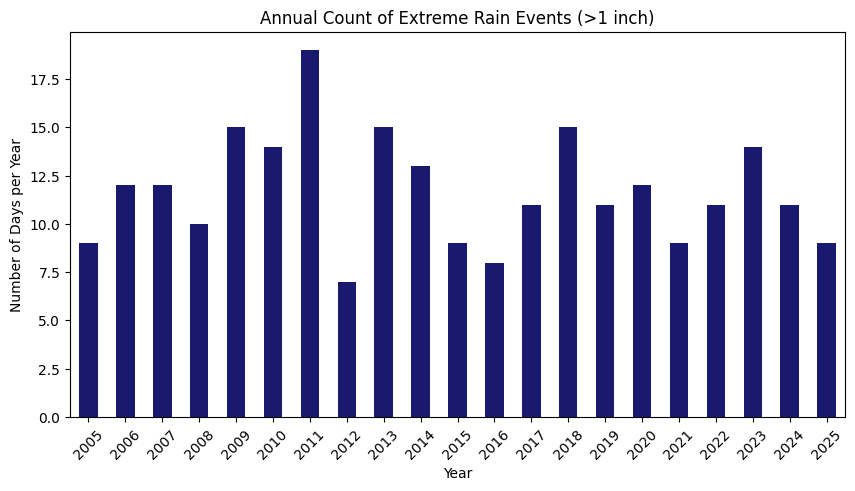

In [7]:
plt.figure(figsize=(10, 5))
heavy_rain_annual.plot(kind='bar', color='midnightblue')

plt.title('Annual Count of Extreme Rain Events (>1 inch)')
plt.ylabel('Number of Days per Year')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

The amount of extreme rain events as defined above seems to be pretty average. There is a significant inrease in frequency for count of extreme rain events in 2011, which matches the previous graph as it having a much higher average amount of rain. Thus, in 2011, not only was there a lot more rainfall, each time it rained, it rained a lot. Furthermore, given that the frequenccy of the extreme rain events seems to be pretty consistent within the last 7-8 years. Although 2025 marked a low for rain count, the total number of rain days remained similar to previous years, indicating that in actuality it isn't raining much in general. 

### Are 'False Spring's' or 'Late Freezes' Becoming more common?

A 'False Spring' occurs when a warm spell in February or March is followed by a sharp freeze. A 'Late Freeze' is when describes the same phenomenon. This volatile pattern is something of concern because it can kill local vegetation that began to bud early. We will look for days where the temperature dropped by a significant margin (e.g., 20+ degrees) within a 48-hour window in the spring.

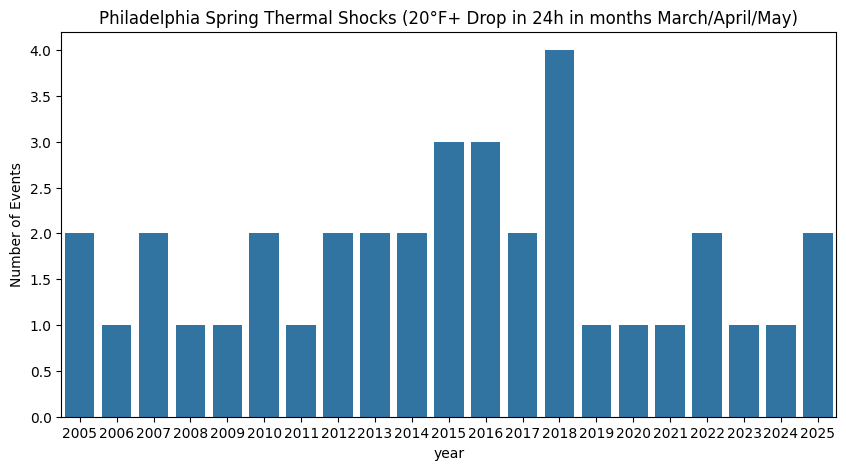

In [8]:
# Calculate the change in 'high' temperature from the previous day
weather_df['temp_change'] = weather_df['high'].diff()

# Defining a 'Thermal Shock' as a 20-degree drop in 24 hours during Spring (March/April/May)
spring_shocks = weather_df[(weather_df['month_num'].isin([3, 4, 5])) & (weather_df['temp_change'] <= -20)]

# Count these shocks per year
annual_shocks = spring_shocks.groupby('year').size()

plt.figure(figsize=(10, 5))
sns.barplot(x=annual_shocks.index, y=annual_shocks.values)
plt.title('Philadelphia Spring Thermal Shocks (20°F+ Drop in 24h in months March/April/May)')
plt.ylabel('Number of Events')
plt.show()

The number of days where there were spring thermal shocks is most likelye either one day or two days out of teh year. However, there is a period in 2012 to 2018 where the minimum was 2 and the maximum was 4 days where this event happened. However, because across the 20 year dataset, the largest difference in the number of days where this event occured was just three days, it is hard to whether this phenomenon has changed in a significant way across the years. 

### How predictable are the temperatures of each month?

If the weather is more volatile and unpredictable, the standard deviations of the month should be increasing. Thus, we can compare the standard deiations across the years to see if this is the case. 


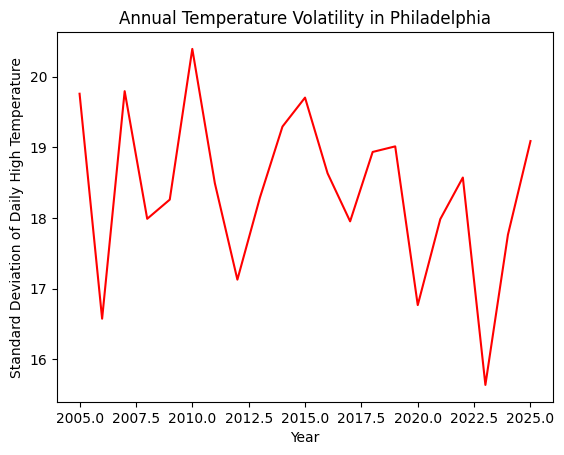

In [19]:
weather_df["year"] = weather_df["date"].dt.year

yearly_volatility = (
    weather_df.groupby("year")["high"]
      .std()
      .reset_index(name="temp_std")
)


sns.lineplot(
    data=yearly_volatility,
    x="year",
    y="temp_std",
    color= "red"
)

plt.title("Annual Temperature Volatility in Philadelphia")
plt.xlabel("Year")
plt.ylabel("Standard Deviation of Daily High Temperature")
plt.show()


Rather than increasing monotonically, the temperature volatility fluctuates every year, indicating that variability is inherent to Philadelphia's weather. Rather than the standard deviation consistently increasing, we see that adist the fluctuations, the global minimum actually occurs in 2022. Short-term drops in volatility are followed by rapid rebounds.  Overall variability remains relatively high across the entire time span. 
The standard deviation consistently stays within a fairly narrow band (roughly mid-to-high teens), indicating that Philadelphia has experienced substantial temperature variability throughout the period studied.

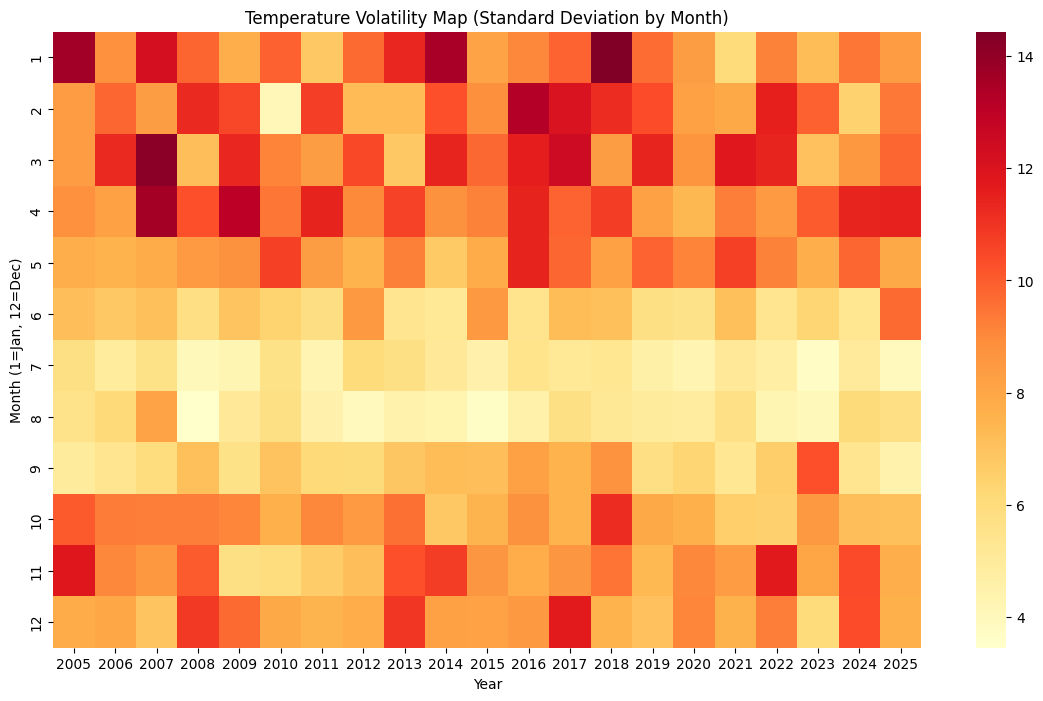

In [23]:
# Calculate the standard deviation of 'high' temps for every month/year
monthly_std = weather_df.groupby(['year', 'month_num'])['high'].std().reset_index()

heatmap_data = monthly_std.pivot(index="month_num", columns="year", values="high")

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False)
plt.title('Temperature Volatility Map (Standard Deviation by Month)')
plt.xlabel('Year')
plt.ylabel('Month (1=Jan, 12=Dec)')
plt.show()

^ An alternate representation of the same data as a heat-map. 

### Conclusions

It is hard over a 20 year period to determine whetehr Philadelphia's weather thas honestly gotten that more drastically different. The graphs largely showed a tight band of variance across different facets of the weather. This isn't to say that the climate has not changed. 

One major limitation of this study is the length of the dataset. Datasets that are respected to truly document drastic changes in the weather as proof of climate change span a lot longer than the current one. This is because there are a myriad of additional effects that cause weather fluctuations, not necessarily climage change. 

Furthermore, another limit of this study is that climate change manifests differently across different seasons. Thus, doing blanket observations without sectioning off by season enough can result in a not thorough enough analysis. 

Finally, through this study, I learned a lot about how to create visually engaging graphs and using data to answer a questions. It was fun to explore how to create a graph as complex as a heatmap. 
